In [46]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [47]:
image_folder = "flood_dataset"

files = [f for f in os.listdir(image_folder) 
         if f.endswith((".png", ".jpg", ".jpeg"))]

print("Files:", files)

Files: ['img4.jpeg', 'img8.jpeg', 'img9.jpeg', 'img5.jpeg', 'img2.jpeg', 'img3.jpeg', 'img1.jpeg', 'img6.jpeg', 'img7.jpeg']


In [62]:
img_path = os.path.join(image_folder, files[4])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(img.shape)

(794, 1122, 3)


In [50]:
def create_mask(img):
    colors = np.array([
        [0,255,0],      # very low
        [100,255,100],  # low
        [0,255,255],    # medium
        [0,0,255],      # high
        [0,0,139]       # very high
    ])

    img_flat = img.reshape(-1, 3)

    distances = np.linalg.norm(img_flat[:, None] - colors, axis=2)

    mask = np.argmin(distances, axis=1)

    return mask.reshape(img.shape[0], img.shape[1])

In [51]:
images = []
masks = []

for filename in files:
    img_path = os.path.join(image_folder, filename)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (256,256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = create_mask(img)

    images.append(img)
    masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (9, 256, 256, 3)
Masks shape: (9, 256, 256)


In [52]:
X_train = images
y_train = masks

In [53]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2,2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2,2), strides=2, padding='same')(x)
    x = layers.concatenate([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256,256,3), num_classes=5):
    inputs = layers.Input(input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)

    # Bottleneck
    b1 = conv_block(p3, 256)

    # Decoder
    d1 = decoder_block(b1, c3, 128)
    d2 = decoder_block(d1, c2, 64)
    d3 = decoder_block(d2, c1, 32)

    # Output
    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(d3)

    return Model(inputs, outputs)

In [54]:
model = build_unet()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_45[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 128, 128,  │          0 │ conv2d_46[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_47[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 64, 64,    │          0 │ conv2d_48[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_49[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 32, 32,    │          0 │ conv2d_50[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_11… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_51[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 64, 64,    │    131,200 │ conv2d_52[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_50[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 64, 64,    │    295,040 │ concatenate_9[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_53[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 128, 128,  │     32,832 │ conv2d_54[0][0] 

 Total params: 1,925,733 (7.35 MB)

 Trainable params: 1,925,733 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.9961 - loss: 0.0110
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.9962 - loss: 0.0107
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9960 - loss: 0.0108
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9966 - loss: 0.0097
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.9968 - loss: 0.0092
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.9969 - loss: 0.0088
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9973 - loss: 0.0078
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.9974 - loss: 0.0076
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.9975 - loss: 0.0073
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.9980 - loss: 0.0064
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.9982 - loss: 0.0058
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.9977 - lo

In [64]:
idx = np.random.randint(0, len(images))

test_img = images[idx]
true_mask = masks[idx]

In [65]:
prediction = model.predict(np.expand_dims(test_img, axis=0))
pred_mask = np.argmax(prediction, axis=-1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


In [66]:
accuracy = np.sum(pred_mask == true_mask) / true_mask.size
print("Pixel Accuracy:", accuracy)

Pixel Accuracy: 0.999786376953125


Filename: img3.jpeg


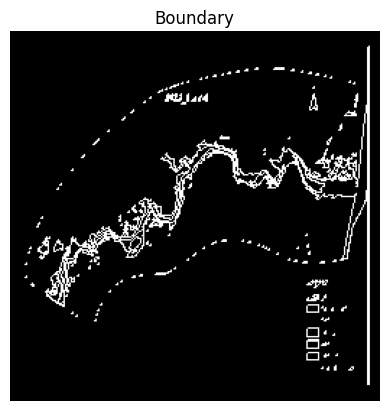

In [70]:
boundary = np.zeros_like(pred_mask)

boundary[:, :-1] |= (pred_mask[:, :-1] != pred_mask[:, 1:])
boundary[:-1, :] |= (pred_mask[:-1, :] != pred_mask[1:, :])

boundary = boundary.astype(np.uint8) * 255
print("Filename:", files[idx])

plt.imshow(boundary, cmap='gray')
plt.title("Boundary")
plt.axis('off')
plt.show()

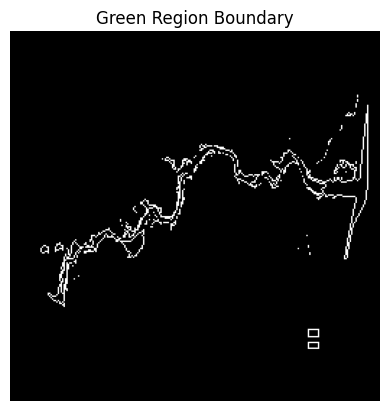

In [68]:
green = (pred_mask == 2).astype(np.uint8)

contours, _ = cv2.findContours(green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boundary_green = np.zeros_like(green)

cv2.drawContours(boundary_green, contours, -1, 255, 1)

plt.imshow(boundary_green, cmap='gray')
plt.title("Green Region Boundary")
plt.axis('off')
plt.show()

Filename: img3.jpeg


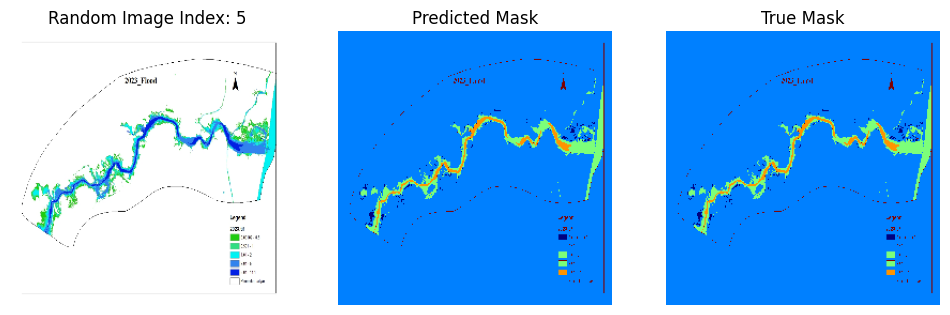

In [71]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(test_img)
plt.title(f"Random Image Index: {idx}")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap='jet')
plt.title("Predicted Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(true_mask, cmap='jet')
plt.title("True Mask")
plt.axis('off')
print("Filename:", files[idx])
plt.show()